## MSM.jl and MacroModelling.jl: estimating a DSGE model

This notebook estimates a toy RBC model with [MSM.jl](https://github.com/JulienPascal/MSM.jl). The model is written, solved and simulated with [MacroModelling.jl](https://github.com/thorek1/MacroModelling.jl) (perturbation solutions at first, second and third order).

The exercise is a controlled experiment, with the goal of testing objective function minimization and inference:

1. take a model with known ("true") parameters;
2. solve it, simulate time series and save them to disk: this is our (fake) "empirical data";
3. estimate the parameters by the method of simulated moments, from the fake data only;
4. check that the true parameters are recovered;
5. repeat on many fake datasets (Monte Carlo), to check the inference: 95% confidence intervals should contain the true value about 95% of the time, and the J-test should reject about 5% of the time at the 5% level.

**Environment.** This notebook has its own environment (`notebooks/models/Project.toml`), because MacroModelling.jl is a heavy dependency (and requires Optim 1). Install it once with `julia --project=notebooks/models -e 'using Pkg; Pkg.instantiate()'`.

### Settings

In [ ]:
# Perturbation order: :first_order, :pruned_second_order or :pruned_third_order
order_true_model = :first_order              # model that generates the fake data
order_estimated_model = order_true_model     # model that is estimated (a different order = a misspecified model)

T = 200                    # length of the fake data (quarters)
simulationRatio = 10       # the simulated sample has simulationRatio*T periods
burnIn = 200               # periods dropped at the start of each simulation
nbSimulationsSigma0 = 500  # simulated datasets used for the model-based Sigma0

# Monte Carlo
nbDatasets = 500           # number of fake datasets per sample size.
sampleSizes = [200, 2000]  # sample sizes of the Monte Carlo
nbSimulationsTrueSigma0 = 4000   # simulated datasets used for the true Sigma0 (benchmark)

addWorkers = true
maxNumberWorkers = 10      # number of workers used when minimizing

In [2]:
using Distributed

if addWorkers == true && nworkers() < maxNumberWorkers
    # the workers use the environment of this notebook
    addprocs(maxNumberWorkers - (nprocs() - 1), exeflags = "--project=$(Base.active_project())")
end
println("Number of workers = $(nworkers())")

Number of workers = 10


In [3]:
using Plots
using CSV
using DataFrames
# MacroModelling also exports Normal: import the names of Distributions explicitly
using Distributions: Normal, Chisq, pdf
@everywhere using MSM
@everywhere using MacroModelling
@everywhere using Optim
@everywhere using OrderedCollections
@everywhere using Random
@everywhere using LinearAlgebra
@everywhere using Logging
# MacroModelling exports its own mean, std, cov...: import the ones of Statistics explicitly
@everywhere using Statistics: mean, std, median, cov, quantile

# Hide the messages of level Info: MSM.jl logs one for each failed evaluation of the model
# (e.g. when the local optimizer tries parameter values for which the model has no stable solution)
@everywhere disable_logging(Logging.Info)

### The model

Let's consider a plain-vanilla real business cycle model, with consumption $c$, capital $k$, output $y$ and technology $z$:

$$\frac{1}{c_t} = \beta \, E_t \left[ \frac{1}{c_{t+1}} \left( \alpha e^{z_{t+1}} k_t^{\alpha - 1} + 1 - \delta \right) \right]$$
$$c_t + k_t = (1 - \delta) k_{t-1} + y_t$$
$$y_t = e^{z_t} k_{t-1}^{\alpha}$$
$$z_t = \rho z_{t-1} + \sigma_z \epsilon_t$$

**Non-stochastic steady state.** Without shocks ($\epsilon_t = 0$ for all $t$), the economy converges to a steady state where every variable is constant: $z = 0$, and $c$, $k$ and $y$ do not depend on $t$. The four equations become:

* Euler equation: $\dfrac{1}{c} = \dfrac{\beta}{c} \left( \alpha k^{\alpha - 1} + 1 - \delta \right)$, $\rightarrow$ $\alpha k^{\alpha - 1} = \dfrac{1}{\beta} - 1 + \delta$, and $k = \left( \frac{1/\beta - 1 + \delta}{\alpha} \right)^{\frac{1}{\alpha - 1}};$
* production function: $y = k^{\alpha}$;
* resource constraint: $c + k = (1 - \delta) k + y$, so $c = y - \delta k$.

MacroModelling.jl can find the steady state numerically, but when it has a closed form, we can give it as a function (`rbc_steady_state!` below), which is faster and more accurate. The function receives the parameters in the order in which they are declared in `@parameters` ($\sigma_z, \rho, \delta, \alpha, \beta$), and fills the steady state of the variables in alphabetical order ($c, k, y, z$, see `get_variables(RBC)`). With the calibration below, it gives the same steady state as the numerical solver (to $10^{-13}$), and solving and simulating the model is about 3 times faster.

The calibration is quarterly: $\beta = 0.99$, $\delta = 0.025$, $\alpha = 0.33$, $\rho = 0.9$ and $\sigma_z = 0.7\%$. We estimate $(\alpha, \rho, \sigma_z)$ and hold $\beta$ and $\delta$ fixed at their true values.

**A standard deviation must be positive.** Instead of imposing $\sigma_z > 0$ as a constraint (which is also possible), we estimate its logarithm: the third parameter is $x = \log(\sigma_z)$, with $\sigma_z$ in percent, and the model is solved with $\sigma_z = \exp(x)$, which is positive for any real number $x$. The optimizer is then free to try any value of $x$. The estimate of $\sigma_z$ and its confidence interval are recovered from those of $x$ at the end (see "Back to $\sigma_z$" below). Expressing $\sigma_z$ in percent keeps the three parameters at a similar order of magnitude, which helps the local optimizer.

The model is defined on every worker: the model object is mutable and stores its solution, so each worker needs its own copy.

In [4]:
@everywhere begin
    @model RBC begin
        1  /  c[0] = (β  /  c[1]) * (α * exp(z[1]) * k[0]^(α - 1) + (1 - δ))
        c[0] + k[0] = (1 - δ) * k[-1] + y[0]
        y[0] = exp(z[0]) * k[-1]^α
        z[0] = ρ * z[-1] + std_z * eps_z[x]
    end

    # Analytical non-stochastic steady state (see above). The parameters arrive in the order of the
    # @parameters block; the steady state is filled in the alphabetical order of the variables: c, k, y, z
    function rbc_steady_state!(ss, params)
        std_z, ρ, δ, α, β = params
        k = ((1 / β - 1 + δ) / α)^(1 / (α - 1))
        y = k^α
        ss[1] = y - δ * k    # c
        ss[2] = k            # k
        ss[3] = y            # y
        ss[4] = 0.0          # z
    end

    @parameters RBC steady_state_function = rbc_steady_state! silent = true begin
        std_z = 0.007
        ρ = 0.9
        δ = 0.025
        α = 0.33
        β = 0.99
    end
end

# True values of the estimated parameters: alpha, rho, and the logarithm of std_z (std_z in percent)
parameterNames = ["alpha", "rho", "log_std_z"]
trueValues = [0.33, 0.9, log(0.7)]
@everywhere trueValues = $trueValues #equivalent of sendto(workers(), .)

### Simulating the model

`simulate_series` solves the model at the parameter values `θ` and simulates it with a given matrix of shocks (1 × periods). Passing the shocks, instead of drawing them inside the function, is what keeps the randomness fixed during the estimation: the same shocks are used for every value of `θ`.

The function returns 100 × log of consumption and of output (so that deviations read as percentages), after the burn-in period. If the model has no stable solution at `θ`, MacroModelling.jl throws an error, and MSM.jl's objective function then returns its penalty value.

**A faster simulation at first order.** The estimation simulates the model thousands of times, so the speed of `simulate_series` matters. MacroModelling.jl can simulate the model itself (`get_irf`), and the function does so at the second and third orders. At first order, the solution is linear, and it is much faster (about 10 times here) to ask MacroModelling.jl only for the solution and to simulate it ourselves. `get_solution` returns a table `S` with one column per variable ($c, k, y, z$): row 1 is the steady state, and rows 2 to 4 give the response of each variable to the deviation of capital from its steady state in the previous period, to technology in the previous period, and to the shock of the current period. Starting at the steady state, each period:

$$\hat{x}_t = S_{2,x} \, \hat{k}_{t-1} + S_{3,x} \, z_{t-1} + S_{4,x} \, \epsilon_t \quad \text{for } x = c, k, y, z,$$

where $\hat{x}_t$ is the deviation of $x_t$ from its steady state, and $x_t = S_{1,x} + \hat{x}_t$. This loop is written for this model (two state variables, capital and technology, and one shock). It gives the same series as `get_irf`.

In [5]:
@everywhere function simulate_series(θ, shocks; algorithm = :first_order, burnIn = 200)
    parameters = [:α => θ[1], :ρ => θ[2], :std_z => exp(θ[3]) / 100, :δ => 0.025, :β => 0.99]

    # Pruned second or third order: MacroModelling.jl simulates the model
    if algorithm != :first_order
        x = get_irf(RBC, parameters = parameters, shocks = shocks, periods = 0, levels = true, algorithm = algorithm, variables = [:c, :y])
        logC = 100 .* log.(vec(x(:c, :, :))[burnIn+1:end])
        logY = 100 .* log.(vec(x(:y, :, :))[burnIn+1:end])
        return logC, logY
    end

    # First order: the solution is linear. 
    # Not necessary, but much faster (10x) when linear.
    # Columns of S: c, k, y, z. Row 1: steady state.
    # Rows 2 to 4: response to capital and technology of the previous period (deviations
    # from the steady state) and to the shock of the current period
    S = Matrix{Float64}(get_solution(RBC, parameters = parameters))
    nbPeriods = size(shocks, 2)
    logC = zeros(nbPeriods - burnIn)
    logY = zeros(nbPeriods - burnIn)
    k̂, ẑ = 0.0, 0.0                    # start at the steady state
    for t in 1:nbPeriods
        ε = shocks[1, t]
        ĉ = S[2, 1] * k̂ + S[3, 1] * ẑ + S[4, 1] * ε
        ŷ = S[2, 3] * k̂ + S[3, 3] * ẑ + S[4, 3] * ε
        k̂, ẑ = S[2, 2] * k̂ + S[3, 2] * ẑ + S[4, 2] * ε, S[2, 4] * k̂ + S[3, 4] * ẑ + S[4, 4] * ε
        if t > burnIn
            logC[t - burnIn] = 100 * log(S[1, 1] + ĉ)
            logY[t - burnIn] = 100 * log(S[1, 3] + ŷ)
        end
    end
    return logC, logY
end


### Moments

We match 7 moments of log consumption and log output: the two means, the two variances, the covariance, and the two first-order autocovariances. With 3 parameters, this leaves 4 over-identifying restrictions for the J-test.

Each moment is the average over time of a "contribution": for instance the variance of $c$ is the average of $(c_t - \bar{c})^2$. `moment_contributions` returns the matrix of these contributions (one row per period, one column per moment). The moments are the column means, and the long-run variance of the columns is $\Sigma_0$, the variance of the empirical moments.

In [6]:
@everywhere momentNames = ["mean_c", "mean_y", "var_c", "var_y", "cov_cy", "autocov_c", "autocov_y"]

@everywhere function moment_contributions(logC, logY)
    dC = logC .- mean(logC)
    dY = logY .- mean(logY)
    t = 2:length(logC)
    return hcat(logC[t], logY[t], dC[t].^2, dY[t].^2, dC[t] .* dY[t], dC[t] .* dC[t.-1], dY[t] .* dY[t.-1])
end

# Moments (column means of the contributions) of the model simulated at θ
@everywhere function simulated_moments(θ, shocks; algorithm = :first_order, burnIn = 200)
    logC, logY = simulate_series(θ, shocks, algorithm = algorithm, burnIn = burnIn)
    return vec(mean(moment_contributions(logC, logY), dims = 1))
end

# Model-based Sigma0: nObs times the variance of the moments across datasets of length T simulated at θ
@everywhere function model_Sigma0(θ, T; nbSimulations = 500, algorithm = :first_order, burnIn = 200)
    M = reduce(hcat, [simulated_moments(θ, randn(1, T + burnIn), algorithm = algorithm, burnIn = burnIn) for _ in 1:nbSimulations])
    return (T - 1) .* cov(M')
end

### Fake data

We simulate $T$ quarters at the true parameter values, save the series to a CSV file, and read the file back: from here on, the file plays the role of the empirical data.

In [7]:
Random.seed!(1234)
logC, logY = simulate_series(trueValues, randn(1, T + burnIn), algorithm = order_true_model, burnIn = burnIn)
CSV.write("fake_data_RBC.csv", DataFrame(quarter = 1:T, log_c = logC, log_y = logY))

data = CSV.read("fake_data_RBC.csv", DataFrame)
first(data, 5)

Row,quarter,log_c,log_y
,Int64,Float64,Float64
1,1,81.3055,107.576
2,2,81.2056,107.207
3,3,81.0743,106.766
4,4,81.3348,108.142
5,5,81.6248,109.347


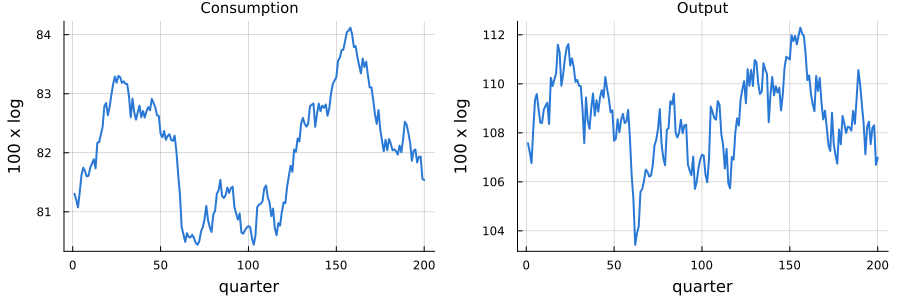

In [8]:
colorModel = "#2a78d6"      # blue
colorNW = "#eb6834"         # orange
colorBenchmark = "#a8a7a2"  # neutral gray

p1 = plot(data.quarter, data.log_c, color = colorModel, linewidth = 2, legend = false, title = "Consumption", titlefontsize = 10,
          xlabel = "quarter", ylabel = "100 x log", gridalpha = 0.3)
p2 = plot(data.quarter, data.log_y, color = colorModel, linewidth = 2, legend = false, title = "Output", titlefontsize = 10,
          xlabel = "quarter", ylabel = "100 x log", gridalpha = 0.3)
plot(p1, p2, layout = (1, 2), size = (900, 300), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

### Setting up the MSM problem

`build_problem` creates the `MSMProblem` from the moment contributions of the data and from the shocks of the simulated sample (drawn once). It is defined on every worker, because the Monte Carlo below calls it there.

In [9]:
@everywhere function build_problem(contributions, simulationShocks; algorithm = :first_order, burnIn = 200, maxFuncEvals = 10000)

    problem = MSMProblem(options = MSMOptions(maxFuncEvals = maxFuncEvals, globalOptimizer = :dxnes, localOptimizer = :LBFGS))

    # Priors: [starting value, lower bound, upper bound]
    priors = OrderedDict{String,Array{Float64,1}}()
    priors["alpha"] = [0.3, 0.1, 0.6]
    priors["rho"] = [0.8, 0.0, 0.99]
    priors["log_std_z"] = [log(1.0), log(0.1), log(3.0)]    # std_z between 0.1% and 3%
    set_priors!(problem, priors)

    # Empirical moments
    empiricalMoments = OrderedDict{String,Array{Float64,1}}()
    for (name, value) in zip(momentNames, vec(mean(contributions, dims = 1)))
        empiricalMoments[name] = [value]
    end
    set_empirical_moments!(problem, empiricalMoments)

    # Simulated moments: same shocks for every θ
    set_simulate_empirical_moments!(problem, θ -> OrderedDict{String,Float64}(zip(momentNames, simulated_moments(θ, simulationShocks, algorithm = algorithm, burnIn = burnIn))))

    return problem
end

# Local minimization from x0 with the weight matrix inv(Sigma0), then inference with Sigma0
@everywhere function estimate_and_infer!(problem, Sigma0, x0, nObs, nSim)
    set_weight_matrix!(problem, Matrix(inv(Sigma0)))
    construct_objective_function!(problem)
    optimResults = msm_localmin(problem, x0, verbose = false)
    θ = Optim.minimizer(optimResults)
    set_Sigma0!(problem, Matrix(Sigma0))
    calculate_Avar!(problem, θ, tau = nObs / nSim)
    se = [calculate_se(problem, nObs, i) for i in 1:length(θ)]
    J, criticalValue = J_test(problem, θ, nObs, nSim, 0.05)
    return (θ = θ, se = se, J = J, reject = J > criticalValue, converged = Optim.converged(optimResults))
end

In [10]:
contributions = moment_contributions(data.log_c, data.log_y)
nObs = size(contributions, 1)       # number of observations used for the moments
nSim = simulationRatio * T          # length of the simulated sample

Random.seed!(5678)
simulationShocks = randn(1, nSim + burnIn)

myProblem = build_problem(contributions, simulationShocks, algorithm = order_estimated_model, burnIn = burnIn)

DataFrame(moment = momentNames, data = vec(mean(contributions, dims = 1)),
          model_at_true_values = simulated_moments(trueValues, simulationShocks, algorithm = order_estimated_model, burnIn = burnIn))

Row,moment,data,model_at_true_values
,String,Float64,Float64
1,mean_c,82.0676,83.7779
2,mean_y,108.715,110.596
3,var_c,0.902236,2.15062
4,var_y,2.75025,4.28451
5,cov_cy,1.26371,2.6292
6,autocov_c,0.887569,2.13981
7,autocov_y,2.44398,4.03506


### Step 1: estimation with a Newey-West $\Sigma_0$

$\Sigma_0$ is first estimated from the data, with the Newey-West estimator (`cov_NW`), and the weight matrix is $W = \Sigma_0^{-1}$. The global optimizer runs in parallel on the workers, and a local optimizer then refines its result.

In [11]:
Sigma0_NW = cov_NW(contributions)
set_weight_matrix!(myProblem, Matrix(inv(Sigma0_NW)))
construct_objective_function!(myProblem)

@time msm_optimize!(myProblem, verbose = false)
println("Global optimizer: minimizer = $(round.(msm_minimizer(myProblem), digits = 4)), minimum = $(msm_minimum(myProblem))")

msm_refine_globalmin!(myProblem, verbose = false)
println("Local refinement: minimizer = $(round.(msm_local_minimizer(myProblem), digits = 4)), minimum = $(msm_local_minimum(myProblem))")

step1 = estimate_and_infer!(myProblem, Sigma0_NW, msm_local_minimizer(myProblem), nObs, nSim)
println("True values                 = $(trueValues)")

 77.529479 seconds (5.91 M allocations: 312.603 MiB, 0.07% gc time, 2.83% compilation time: <1% of which was recompilation)
Global optimizer: minimizer = [0.327, 0.8159, -0.2683], minimum = 0.0051766576674636446
Local refinement: minimizer = [0.327, 0.8159, -0.2683], minimum = 0.005176657667467758
True values                 = [0.33, 0.9, -0.35667494393873245]



True values                 = [0.33, 0.9, -0.35667494393873245]

### Step 2: model-based $\Sigma_0$

Log consumption and log output are very persistent (they inherit the persistence of capital), and the Newey-West estimator is known to underestimate the long-run variance of persistent series in samples of this size. **An alternative uses the model itself**. This is what is recommended in Burnside and Eichenbaum (1996): *"we can use the structural model itself to generate an estimate of [the variance-covariance matrix]"*. Here, we simulate many datasets of length $T$ at the step 1 estimate, compute the moments of each, and take the variance of these moments across datasets. We then re-estimate with $W = \Sigma_0^{-1}$, and repeat once at the new estimate.

**Reference**
* Burnside, Craig, and Martin Eichenbaum. "Small-sample properties of GMM-based Wald tests." Journal of Business & Economic Statistics 14.3 (1996): 294-308.

In [12]:
Random.seed!(91011)
Sigma0_model = model_Sigma0(step1.θ, T, nbSimulations = nbSimulationsSigma0, algorithm = order_estimated_model, burnIn = burnIn)
step2 = estimate_and_infer!(myProblem, Sigma0_model, step1.θ, nObs, nSim)

Sigma0_model = model_Sigma0(step2.θ, T, nbSimulations = nbSimulationsSigma0, algorithm = order_estimated_model, burnIn = burnIn)
step2 = estimate_and_infer!(myProblem, Sigma0_model, step2.θ, nObs, nSim)

DataFrame(moment = momentNames, std_Newey_West = sqrt.(diag(Sigma0_NW)), std_model_based = sqrt.(diag(Sigma0_model)))

Row,moment,std_Newey_West,std_model_based
,String,Float64,Float64
1,mean_c,2.6073,6.93556
2,mean_y,4.11236,7.95504
3,var_c,2.36996,5.1825
4,var_y,8.26608,9.24041
5,cov_cy,4.01802,6.06849
6,autocov_c,2.36593,5.18273
7,autocov_y,8.23605,9.17086


The table above compares the long-run standard deviations of the moment contributions under the two estimators. The table below gives the estimates, their standard errors and 95% confidence intervals.

In [13]:
z975 = quantile(Normal(), 0.975)    # 97.5% quantile of the normal distribution: 95% confidence intervals
results = DataFrame(Sigma0 = String[], parameter = String[], true_value = Float64[], estimate = Float64[], std_error = Float64[],
                    CI_lower = Float64[], CI_upper = Float64[], true_value_in_CI = Bool[])
for (label, step) in [("Newey-West", step1), ("model-based", step2)], i in 1:length(trueValues)
    lower = step.θ[i] - z975 * step.se[i]
    upper = step.θ[i] + z975 * step.se[i]
    push!(results, (label, parameterNames[i], trueValues[i], step.θ[i], step.se[i], lower, upper, lower <= trueValues[i] <= upper))
end
results

Row,Sigma0,parameter,true_value,estimate,std_error,CI_lower,CI_upper,true_value_in_CI
,String,String,Float64,Float64,Float64,Float64,Float64,Bool
1,Newey-West,alpha,0.33,0.327013,0.000346083,0.326335,0.327691,false
2,Newey-West,rho,0.9,0.815874,0.0225079,0.771759,0.859988,false
3,Newey-West,log_std_z,-0.356675,-0.268312,0.0768736,-0.418982,-0.117642,true
4,model-based,alpha,0.33,0.327242,0.000906305,0.325466,0.329019,false
5,model-based,rho,0.9,0.840739,0.0287775,0.784336,0.897141,false
6,model-based,log_std_z,-0.356675,-0.294412,0.0562122,-0.404586,-0.184238,true


### Back to $\sigma_z$

The third row of each block above is $x = \log(\sigma_z)$. To report $\sigma_z = \exp(x)$ itself:

* **estimate**: $\hat{\sigma}_z = \exp(\hat{x})$;
* **confidence interval**: apply $\exp$ to the two bounds of the interval for $x$. The function is increasing, so the transformed interval contains the true $\sigma_z$ exactly when the interval for $x$ contains the true $x$: the coverage is the same. The interval is not symmetric around $\hat{\sigma}_z$, and it cannot contain negative values;
* **standard error**: by the Delta method, $se(\hat{\sigma}_z) \approx \exp(\hat{x}) \, se(\hat{x})$.

One caution: for $x$, the t-statistic and the p-value of the summary table below test $x = 0$, that is $\sigma_z = 1$. They are not a test of $\sigma_z = 0$.


In [14]:
# std_z = exp(log_std_z), in percent
backTransformed = DataFrame(Sigma0 = String[], parameter = String[], true_value = Float64[], estimate = Float64[],
                            std_error_delta_method = Float64[], CI_lower = Float64[], CI_upper = Float64[])
for (label, step) in [("Newey-West", step1), ("model-based", step2)]
    x, se = step.θ[3], step.se[3]
    push!(backTransformed, (label, "std_z", exp(trueValues[3]), exp(x), exp(x) * se, exp(x - z975 * se), exp(x + z975 * se)))
end
backTransformed


Row,Sigma0,parameter,true_value,estimate,std_error_delta_method,CI_lower,CI_upper
,String,String,Float64,Float64,Float64,Float64,Float64
1,Newey-West,std_z,0.7,0.764669,0.0587829,0.657716,0.889014
2,model-based,std_z,0.7,0.74497,0.0418764,0.667253,0.831738


In [15]:
# J-test (4 over-identifying restrictions), with the model-based Sigma0: MSM.jl's summary table and test
minimizer = step2.θ
show(stdout, MIME("text/plain"), summary_table(myProblem, minimizer, nObs, 0.05))
J, criticalValue = J_test(myProblem, minimizer, nObs, nSim, 0.05)
println("\nJ-test: J = $(round(J, digits = 2)), critical value at 5% = $(round(criticalValue, digits = 2)): the model is $(J > criticalValue ? "rejected" : "not rejected")")

──────────────────────────────────────────────────────────────────
        Coef.   Std. Error       t  Pr(>|t|)   CI Lower   CI Upper
──────────────────────────────────────────────────────────────────
x1   0.327242  0.000906305  361.07    <1e-99   0.325466   0.329019
x2   0.840739  0.0287775     29.22    <1e-99   0.784336   0.897141
x3  -0.294412  0.0562122     -5.24    <1e-06  -0.404586  -0.184238
──────────────────────────────────────────────────────────────────
J-test: J = 4.26, critical value at 5% = 9.49: the model is not rejected


        Coef.   Std. Error       t  Pr(>|t|)   CI Lower   CI Upper
──────────────────────────────────────────────────────────────────
x1   0.327242  0.000906305  361.07    <1e-99   0.325466   0.329019
x2   0.840739  0.0287775     29.22    <1e-99   0.784336   0.897141
x3  -0.294412  0.0562122     -5.24    <1e-06  -0.404586  -0.184238
──────────────────────────────────────────────────────────────────
J-test: J = 4.26, critical value at 5% = 9.49: the model is not rejected


### Slices of the objective function

The objective function around the estimate, one parameter at a time (model-based weight matrix). The third panel shows $\sigma_z = \exp(x)$ on its horizontal axis, instead of $x = \log(\sigma_z)$.

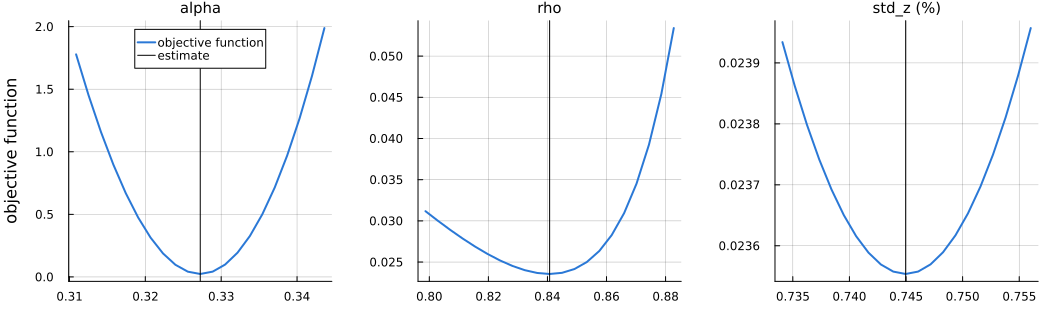

In [16]:
vXGrid, vYGrid = msm_slices(myProblem, minimizer, nbPoints = 21, offset = 0.05)

# The third parameter is log(std_z): shown as std_z = exp(log_std_z), in percent
sliceNames = ["alpha", "rho", "std_z (%)"]
sliceTransforms = [identity, identity, exp]

slicePanels = []
for i in 1:length(minimizer)
    f = sliceTransforms[i]
    p = plot(f.(vXGrid[:, i]), vYGrid[:, i], color = colorModel, linewidth = 2, label = "objective function", title = sliceNames[i], titlefontsize = 10,
             ylabel = i == 1 ? "objective function" : "", gridalpha = 0.3, legend = i == 1 ? :top : false)
    vline!(p, [f(minimizer[i])], color = :black, linewidth = 1, label = "estimate")
    # to plot the true parameter values as well
    #vline!(p, [f(trueValues[i])], color = :black, linestyle = :dash, linewidth = 1, label = "true value")
    push!(slicePanels, p)
end
plot(slicePanels..., layout = (1, 3), size = (1050, 320), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

### Monte Carlo

One dataset says little about the quality of the inference. We now repeat the whole exercise on many fake datasets, for each sample size, and compare three ways of obtaining $\Sigma_0$:

* **Newey-West**, from the data (step 1 above);
* **model-based**, simulated at the estimate (step 2 above, with the two rounds);
* **true $\Sigma_0$**, simulated at the true parameter values with many datasets. It is not available in practice: it is a benchmark, which isolates MSM.jl's formulas (asymptotic variance, J-test) from the estimation of $\Sigma_0$.

Each replication draws new shocks for the data and for the simulated sample. The replications run in parallel, one estimation per worker; each estimation is a local minimization (LBFGS), started from the starting values of the priors for Newey-West, and from the previous estimate for the other two.

In [17]:
@everywhere function estimate_one(replication, T, trueSigma0; algorithmTrue = :first_order, algorithmEstimated = :first_order,
                                  simulationRatio = 10, burnIn = 200, nbSimulationsSigma0 = 500)

    # One seed per dataset and sample size. 
    Random.seed!(1_000_000 * T + replication)

    # Fake data, and shocks of the simulated sample
    logC, logY = simulate_series(trueValues, randn(1, T + burnIn), algorithm = algorithmTrue, burnIn = burnIn)
    contributions = moment_contributions(logC, logY)
    nObs = size(contributions, 1)
    nSim = simulationRatio * T
    problem = build_problem(contributions, randn(1, nSim + burnIn), algorithm = algorithmEstimated, burnIn = burnIn, maxFuncEvals = 10000)
    x0 = [problem.priors[k][1] for k in keys(problem.priors)]

    # Newey-West
    newey = estimate_and_infer!(problem, cov_NW(contributions), x0, nObs, nSim)

    # Model-based, two rounds
    model = estimate_and_infer!(problem, model_Sigma0(newey.θ, T, nbSimulations = nbSimulationsSigma0, algorithm = algorithmEstimated, burnIn = burnIn), newey.θ, nObs, nSim)
    model = estimate_and_infer!(problem, model_Sigma0(model.θ, T, nbSimulations = nbSimulationsSigma0, algorithm = algorithmEstimated, burnIn = burnIn), model.θ, nObs, nSim)

    # True Sigma0 (benchmark)
    benchmark = estimate_and_infer!(problem, trueSigma0, newey.θ, nObs, nSim)

    return OrderedDict("Newey-West" => newey, "model-based" => model, "true Sigma0" => benchmark)
end

# Moments of one dataset simulated at the true values (for the true Sigma0)
@everywhere function true_model_moments(replication, T; algorithm = :first_order, burnIn = 200)
    Random.seed!(1_000_000 * T + 500_000 + replication)      # different from the seeds of estimate_one (replication < 500000)
    return simulated_moments(trueValues, randn(1, T + burnIn), algorithm = algorithm, burnIn = burnIn)
end

In [18]:
sigma0Methods = ["Newey-West", "model-based", "true Sigma0"]
monteCarlo = DataFrame(T = Int[], Sigma0 = String[], replication = Int[], alpha = Float64[], rho = Float64[], log_std_z = Float64[],
                       se_alpha = Float64[], se_rho = Float64[], se_log_std_z = Float64[], J = Float64[], reject = Bool[], converged = Bool[])
nbFailures = Dict()
trueSigma0s = Dict()       # simulated true Sigma0 of each sample size (used in the check below)

for sampleSize in sampleSizes

    # True Sigma0: variance of the moments across many datasets simulated at the true values
    M = reduce(hcat, pmap(r -> true_model_moments(r, sampleSize, algorithm = order_true_model, burnIn = burnIn), 1:nbSimulationsTrueSigma0))
    trueSigma0 = (sampleSize - 1) .* cov(M')
    trueSigma0s[sampleSize] = trueSigma0

    elapsed = @elapsed estimations = pmap(1:nbDatasets) do replication
        try
            estimate_one(replication, sampleSize, trueSigma0, algorithmTrue = order_true_model, algorithmEstimated = order_estimated_model,
                         simulationRatio = simulationRatio, burnIn = burnIn, nbSimulationsSigma0 = nbSimulationsSigma0)
        catch myError
            # Keep why it failed: the type of the error, and the step where it happened
            frames = [string(frame.func) for frame in stacktrace(catch_backtrace())]
            steps = [name for name in ("calculate_D", "msm_localmin", "model_Sigma0") if name in frames]
            (error = string(nameof(typeof(myError))), step = isempty(steps) ? "another step" : first(steps))
        end
    end

    failures = [estimation for estimation in estimations if !(estimation isa OrderedDict)]
    nbFailures[sampleSize] = length(failures)
    for (replication, estimation) in enumerate(estimations)
        estimation isa OrderedDict || continue
        for method in sigma0Methods
            e = estimation[method]
            push!(monteCarlo, (sampleSize, method, replication, e.θ..., e.se..., e.J, e.reject, e.converged))
        end
    end
    println("T = $(sampleSize): $(nbDatasets - nbFailures[sampleSize]) estimations out of $(nbDatasets) in $(round(elapsed / 60, digits = 1)) minutes")
    for failure in unique(failures)
        println("    $(count(==(failure), failures)) failed with a $(failure.error) in $(failure.step)")
    end
end

CSV.write("monte_carlo_RBC.csv", monteCarlo)

T = 200: 490 estimations out of 500 in 1.4 minutes
    4 failed with a DomainError in calculate_D
    6 failed with a AssertionError in msm_localmin
T = 2000: 484 estimations out of 500 in 13.9 minutes
    16 failed with a AssertionError in msm_localmin


"monte_carlo_RBC.csv"

### Monte Carlo: results

For each sample size, method and parameter:

* `bias`: mean of the estimates minus the true value;
* `std_estimates`: standard deviation of the estimates across datasets, i.e. the actual uncertainty;
* `mean_std_error`: average of the standard errors reported by MSM.jl. It should be close to `std_estimates`;
* `coverage_95`: share of the datasets for which the 95% confidence interval contains the true value. It should be close to 0.95.

The third parameter is $\log(\sigma_z)$. Its coverage is also the coverage of the back-transformed interval for $\sigma_z$: the interval for $\log(\sigma_z)$ contains the true value exactly when the back-transformed interval contains the true $\sigma_z$.

In [25]:
coverageTable = DataFrame(T = Int[], Sigma0 = String[], parameter = String[], bias = Float64[], std_estimates = Float64[],
                          mean_std_error = Float64[], coverage_95 = Float64[])
for sampleSize in sampleSizes, method in sigma0Methods, (i, name) in enumerate(parameterNames)
    sub = monteCarlo[(monteCarlo.T .== sampleSize) .& (monteCarlo.Sigma0 .== method), :]
    estimates = sub[!, name]
    stdErrors = sub[!, "se_" * name]
    covered = abs.(estimates .- trueValues[i]) .<= z975 .* stdErrors
    push!(coverageTable, (sampleSize, method, name, mean(estimates) - trueValues[i], std(estimates), mean(stdErrors), mean(covered)))
end
coverageTable

Row,T,Sigma0,parameter,bias,std_estimates,mean_std_error,coverage_95
,Int64,String,String,Float64,Float64,Float64,Float64
1,200,Newey-West,alpha,-4.88181e-5,0.00142763,0.000369012,0.379592
2,200,Newey-West,rho,-0.0443845,0.0595232,0.0198915,0.446939
3,200,Newey-West,log_std_z,-0.00508884,0.0855473,0.0751641,0.9
4,200,model-based,alpha,-8.11336e-5,0.00136564,0.00109177,0.832653
5,200,model-based,rho,-0.0367349,0.100444,0.0331041,0.816327
6,200,model-based,log_std_z,-0.0223564,0.119361,0.0634325,0.865306
7,200,true Sigma0,alpha,-6.5423e-5,0.00132228,0.00131432,0.953061
8,200,true Sigma0,rho,-0.0323315,0.0544823,0.0449223,0.940816
9,200,true Sigma0,log_std_z,-0.0152211,0.0650896,0.0609557,0.95102


The J-test: its rejection rate at the 5% level should be close to 0.05, and the mean of the J statistic close to 4, the number of over-identifying restrictions (the mean of a chi-squared distribution with 4 degrees of freedom). `converged` is the share of the local minimizations that met Optim's convergence criteria.

In [20]:
jTable = DataFrame(T = Int[], Sigma0 = String[], rejection_rate_5 = Float64[], mean_J = Float64[], median_J = Float64[], converged = Float64[])
for sampleSize in sampleSizes, method in sigma0Methods
    sub = monteCarlo[(monteCarlo.T .== sampleSize) .& (monteCarlo.Sigma0 .== method), :]
    push!(jTable, (sampleSize, method, mean(sub.reject), mean(sub.J), median(sub.J), mean(sub.converged)))
end
jTable

Row,T,Sigma0,rejection_rate_5,mean_J,median_J,converged
,Int64,String,Float64,Float64,Float64,Float64
1,200,Newey-West,0.0367347,2.84607,2.18224,1.0
2,200,model-based,0.25102,328.186,4.58043,0.916327
3,200,true Sigma0,0.077551,3.89571,2.13686,0.963265
4,2000,Newey-West,0.0103306,1.36035,0.722658,1.0
5,2000,model-based,0.0681818,4.16827,3.06475,0.828512
6,2000,true Sigma0,0.0640496,3.94451,2.91097,0.845041


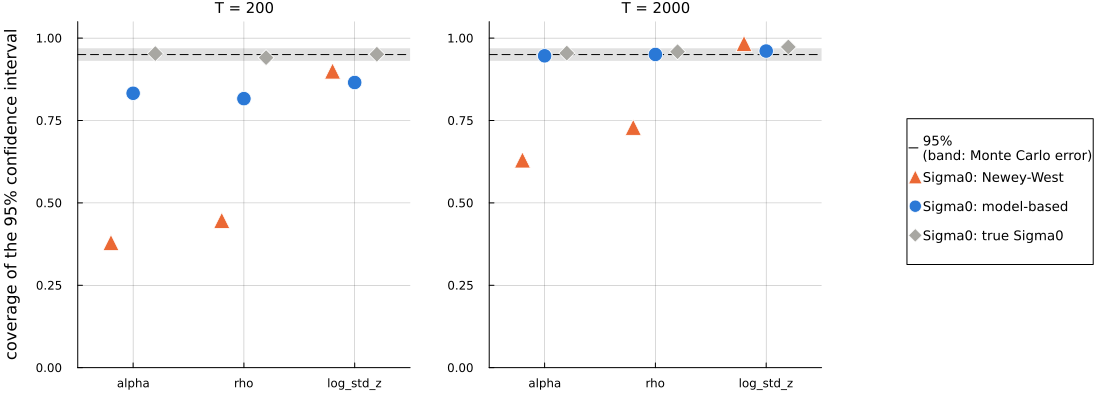

In [21]:
# Coverage of the 95% confidence intervals. The band is the range in which the coverage of a correct
# interval falls 95% of the time, given the number of datasets
methodColors = Dict("Newey-West" => colorNW, "model-based" => colorModel, "true Sigma0" => colorBenchmark)
methodMarkers = Dict("Newey-West" => :utriangle, "model-based" => :circle, "true Sigma0" => :diamond)
methodOffsets = Dict("Newey-West" => -0.2, "model-based" => 0.0, "true Sigma0" => 0.2)
band = z975 * sqrt(0.95 * 0.05 / nbDatasets)

coveragePanels = []
for (k, sampleSize) in enumerate(sampleSizes)
    p = plot(title = "T = $(sampleSize)", titlefontsize = 10, ylims = (0, 1.05), xlims = (0.5, 3.5), xticks = (1:3, parameterNames),
             ylabel = k == 1 ? "coverage of the 95% confidence interval" : "", gridalpha = 0.3, legend = false)
    plot!(p, [0.5, 3.5], [0.95, 0.95], ribbon = band, color = :black, fillalpha = 0.12, linewidth = 1, linestyle = :dash)
    for method in sigma0Methods
        sub = coverageTable[(coverageTable.T .== sampleSize) .& (coverageTable.Sigma0 .== method), :]
        scatter!(p, (1:3) .+ methodOffsets[method], sub.coverage_95, color = methodColors[method], marker = methodMarkers[method],
                 markersize = 8, markerstrokecolor = :white, markerstrokewidth = 1)
    end
    push!(coveragePanels, p)
end
# Legend in its own panel
legendPanel = plot([NaN], [NaN], color = :black, linewidth = 1, linestyle = :dash, label = "95%\n(band: Monte Carlo error)", framestyle = :none,
                   legend = :left, legendfontsize = 9)
for method in sigma0Methods
    scatter!(legendPanel, [NaN], [NaN], color = methodColors[method], marker = methodMarkers[method], markersize = 8,
             markerstrokecolor = :white, markerstrokewidth = 1, label = "Sigma0: " * method)
end
plot(coveragePanels..., legendPanel, layout = grid(1, length(sampleSizes) + 1, widths = [fill(0.78 / length(sampleSizes), length(sampleSizes)); 0.22]),
     size = (1100, 400), left_margin = 5Plots.mm, bottom_margin = 3Plots.mm)

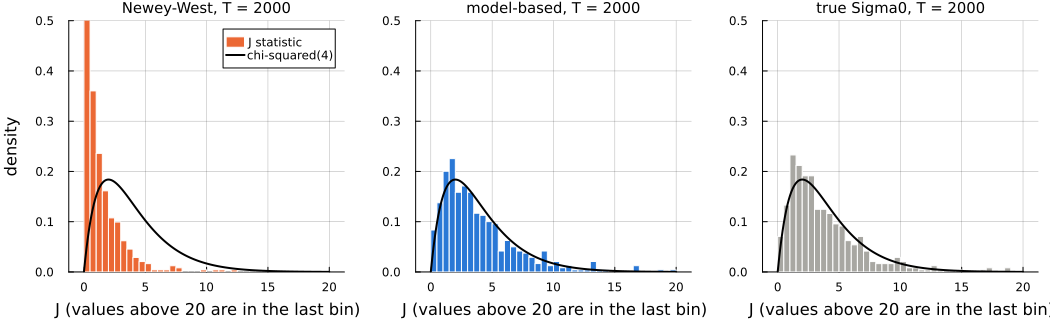

In [22]:
# Distribution of the J statistic (largest sample size), against its theoretical distribution: chi-squared with 4 degrees of freedom
lastSize = sampleSizes[end]
jGrid = range(0, 20, length = 200)
jPanels = []
for (k, method) in enumerate(sigma0Methods)
    sub = monteCarlo[(monteCarlo.T .== lastSize) .& (monteCarlo.Sigma0 .== method), :]
    p = histogram(clamp.(sub.J, 0, 20), bins = range(0, 20, length = 41), normalize = :pdf, color = methodColors[method], linecolor = :white,
                  label = "J statistic", title = "$(method), T = $(lastSize)", titlefontsize = 10, xlabel = "J (values above 20 are in the last bin)",
                  ylabel = k == 1 ? "density" : "", ylims = (0, 0.5), gridalpha = 0.3, legend = k == 1 ? :topright : false)
    plot!(p, jGrid, pdf.(Chisq(4), jGrid), color = :black, linewidth = 2, label = "chi-squared(4)")
    push!(jPanels, p)
end
plot(jPanels..., layout = (1, 3), size = (1050, 320), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

### Check: an analytical $\Sigma_0$ at first order

The true $\Sigma_0$ of the Monte Carlo is obtained by simulation, with a large number of replications (`nbSimulationsTrueSigma0`). When the true model is solved at first order with Gaussian shocks, $\Sigma_0$ also has a closed form, which only involves the autocovariances of the series (Bartlett's formula). `get_statistics` gives the theoretical mean, variance and autocorrelations of each variable, so the autocovariances of each variable with itself: $\Gamma(j) = \text{variance} \times \text{autocorrelation}(j)$. That is enough for the 6 moments that involve a single variable, for which the asymptotic variances are:

* mean: $\Gamma(0) + 2 \sum_{j \geq 1} \Gamma(j)$;
* variance: $2 \left[ \Gamma(0)^2 + 2 \sum_{j \geq 1} \Gamma(j)^2 \right]$;
* first-order autocovariance: $\Gamma(0)^2 + \Gamma(1)^2 + 2 \sum_{j \geq 1} \left[ \Gamma(j)^2 + \Gamma(j+1) \Gamma(j-1) \right]$.

The covariance between consumption and output (`cov_cy`) would need the covariances between $c$ and $y$ at different lags, which `get_statistics` does not provide, so it is not checked. The moments are those of $100 \log(c)$ and $100 \log(y)$: their variance is approximated by $10^4 \times$ the variance of the level divided by the square of its mean (first-order approximation of the logarithm), and the logarithm does not change the autocorrelations.

These formulas give the **asymptotic** $\Sigma_0$ (the limit when $T$ grows). The cell compares it with the simulated true $\Sigma_0$ of each sample size of the Monte Carlo, and with one simulated in a very long sample (100,000 periods), where the two should agree. It only applies when `order_true_model = :first_order`: at higher orders the series are not Gaussian, and the formulas would need fourth-order terms.

**References.** M. S. Bartlett (1946), "On the Theoretical Specification and Sampling Properties of Autocorrelated Time-Series", *Supplement to the Journal of the Royal Statistical Society*, 8, 27–41. P. J. Brockwell and R. A. Davis (1991), *Time Series: Theory and Methods*, 2nd edition, Springer.


In [23]:
@time begin
    
if order_true_model == :first_order

    # Theoretical moments of the levels of c and y at the true values (first-order solution).
    # get_statistics takes the parameter values in the order of the @parameters block: std_z, ρ, δ, α, β
    parameterValues = [exp(trueValues[3]) / 100, trueValues[2], 0.025, trueValues[1], 0.99]
    nbLags = 1500
    theoretical = get_statistics(RBC, parameterValues, mean = [:c, :y], variance = [:c, :y],
                                 autocorrelation = [:c, :y], autocorrelation_periods = 1:(nbLags + 1))

    # Asymptotic variances of the 6 moments that involve a single variable (Bartlett's formula).
    # Rows of the results: c, then y (the order of the variables in the call above)
    analyticalVariance = Dict{String,Float64}()
    for (i, name) in enumerate(["c", "y"])
        # autocovariances of 100*log(x): Γ[j + 1] at lag j
        variance = 1e4 * theoretical[:variance][i] / theoretical[:mean][i]^2
        Γ = [variance; variance .* theoretical[:autocorrelation][i, :]]
        analyticalVariance["mean_" * name] = Γ[1] + 2 * sum(Γ[2:nbLags+1])
        analyticalVariance["var_" * name] = 2 * (Γ[1]^2 + 2 * sum(Γ[2:nbLags+1] .^ 2))
        analyticalVariance["autocov_" * name] = Γ[1]^2 + Γ[2]^2 + 2 * sum(Γ[j+1]^2 + Γ[j+2] * Γ[j] for j in 1:(nbLags - 1))
    end

    # Simulated Sigma0 in a very long sample, where it should be close to the asymptotic one
    longSample = 100000
    M = reduce(hcat, pmap(r -> true_model_moments(r, longSample, algorithm = order_true_model, burnIn = burnIn), 1:2000))
    trueSigma0s[longSample] = (longSample - 1) .* cov(M')

    # Ratio of the simulated variances (true Sigma0 of the Monte Carlo, and long sample) to the analytical ones
    checked = [m for m in momentNames if haskey(analyticalVariance, m)]      # all the moments but cov_cy
    index = [findfirst(==(m), momentNames) for m in checked]
    sigma0Check = DataFrame(moment = checked, analytical_std = sqrt.([analyticalVariance[m] for m in checked]))
    for sampleSize in sort(collect(keys(trueSigma0s)))
        sigma0Check[!, "variance_ratio_T_$(sampleSize)"] = diag(trueSigma0s[sampleSize])[index] ./ [analyticalVariance[m] for m in checked]
    end
    sigma0Check

else
    println("The analytical Sigma0 is only computed when order_true_model = :first_order")
end

end

 20.993885 seconds (52.75 M allocations: 2.835 GiB, 7.64% gc time, 10 lock conflicts, 82.62% compilation time)


Row,moment,analytical_std,variance_ratio_T_200,variance_ratio_T_2000,variance_ratio_T_100000
,String,Float64,Float64,Float64,Float64
1,mean_c,11.1645,0.871107,0.986812,1.03214
2,mean_y,12.353,0.895425,0.991852,1.03306
3,var_c,16.3311,0.444375,0.946299,1.03966
4,var_y,23.4689,0.596943,0.949225,1.05136
5,autocov_c,16.3252,0.443675,0.946233,1.0396
6,autocov_y,23.4319,0.595164,0.949258,1.05096


### Results

**One dataset (T = 200).** The estimates are in the right region. With this particular dataset the true values of $\alpha$ and $\rho$ fall outside their 95% confidence intervals, with both ways of estimating $\Sigma_0$; the true $\sigma_z$ is inside. One dataset cannot tell whether this is bad luck or a problem with the inference: the Monte Carlo can.

**Estimating $\log(\sigma_z)$.** With the model-based $\Sigma_0$, the estimate of $\log(\sigma_z)$ is −0.294 (standard error 0.056), which gives $\hat{\sigma}_z = 0.745$% (true value 0.7%), a delta-method standard error of 0.042, and a 95% confidence interval of [0.667, 0.832]. 

**Monte Carlo.** 490 (T = 200) and 484 (T = 2000) of the 500 estimations succeeded; the others stopped with an error in the local minimization or, for 4 datasets at T = 200, in the computation of the standard errors (`calculate_D`). With this number of datasets, the coverage of a correct 95% confidence interval falls between 93.1% and 96.9% (the gray band of the figure). The bias is the mean of the estimates minus the true value. The median of a chi-squared distribution with 4 degrees of freedom is 3.4.

| T | $\Sigma_0$ | coverage $\alpha$ | coverage $\rho$ | coverage $\log(\sigma_z)$ | bias $\alpha$ | bias $\rho$ | bias $\log(\sigma_z)$ | J-test rejection rate at 5% | median of J |
|---|---|---|---|---|---|---|---|---|---|
| 200 | Newey-West | 38.0% | 44.7% | 90.0% | −0.00005 | −0.0444 | −0.0051 | 3.7% | 2.2 |
| 200 | model-based | 83.3% | 81.6% | 86.5% | −0.00008 | −0.0367 | −0.0224 | 25.1% | 4.6 |
| 200 | true $\Sigma_0$ | 95.3% | 94.1% | 95.1% | −0.00007 | −0.0323 | −0.0152 | 7.8% | 2.1 |
| 2000 | Newey-West | 63.0% | 72.9% | 98.3% | 0.00000 | −0.0031 | −0.0017 | 1.0% | 0.7 |
| 2000 | model-based | 94.6% | 95.0% | 96.1% | −0.00001 | −0.0004 | −0.0019 | 6.8% | 3.1 |
| 2000 | true $\Sigma_0$ | 95.5% | 95.9% | 97.3% | −0.00001 | −0.0003 | −0.0019 | 6.4% | 2.9 |

* **MSM.jl's inference is correct when $\Sigma_0$ is.** With the true $\Sigma_0$, the coverage is within the band for the three parameters at T = 200, and for $\alpha$ and $\rho$ at T = 2000; for $\log(\sigma_z)$ at T = 2000 it is slightly above (97.3%): its standard errors are about 10% too large, which makes the intervals a little conservative. At T = 2000 the J-test rejects 6.4% of the time and the mean of J is 3.9 (4 in theory). At T = 200 the J-test rejects somewhat too often (7.8%), a known small-sample property of this test.
* **The estimates are almost unbiased, except $\rho$ in small samples.** At T = 200, $\rho$ is underestimated by 0.03 to 0.04 on average (true value 0.9), whatever the $\Sigma_0$: the usual small-sample bias of estimated persistence. At T = 2000 the biases are negligible compared with the dispersion of the estimates.
* **The Newey-West $\Sigma_0$ fails here.** The standard errors of $\alpha$ and $\rho$ are 2 to 4 times too small, and the confidence intervals contain the true value far less than 95% of the time, even at T = 2000. Log consumption and log output are very persistent, and the Newey-West estimator underestimates the long-run variance of their moments. The J statistic is too small for the same reason. $\log(\sigma_z)$ is less affected.
* **The model-based $\Sigma_0$ works in large samples.** At T = 2000, coverage (94.6% to 96.1%) and the J-test (6.8% of rejections) are close to those with the true $\Sigma_0$. At T = 200 it improves on Newey-West for $\alpha$ and $\rho$, but coverage is still 9 to 13 points below 95% for the three parameters, and the J-test rejects 25.1% of the time. $\Sigma_0$ is simulated at an estimate of $\rho$ which is biased downwards in small samples, so the persistence, and with it $\Sigma_0$, is underestimated.

**Perturbation order.** Everything above uses the first-order solution for both the true and the estimated model. To study a misspecified model, set `order_true_model` (e.g. `:pruned_third_order`) and `order_estimated_model` (e.g. `:first_order`) to different values in the first cell. In this model with small shocks the orders give almost the same series, so the effect is small. Higher orders are also much slower: the fast simulation loop of `simulate_series` only applies at first order.


In [24]:
versioninfo()

Julia Version 1.13.1
Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)


Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)


---

## Extra: Bayesian estimation with MacroModelling.jl

MacroModelling.jl can also estimate the model by full-information likelihood:
*`get_loglikelihood` evaluates the likelihood of the observed data with the Kalman filter (at first order)
* Turing.jl samples the resulting posterior distribution.
See: https://github.com/thorek1/MacroModelling.jl/blob/main/test/test_estimation.jl.

Here, we estimate the same three parameters on the same fake dataset (`fake_data_RBC.csv`, $T = 200$), to compare with the MSM estimates above.

What differs from the MSM estimation:

* **One observed series.** The model has a single shock (technology), so it implies an exact relationship between consumption and output, which the data would contradict as soon as both are observed ("stochastic singularity"; MacroModelling.jl refuses more observed series than shocks). The likelihood therefore uses **output only**, while MSM matches moments of both consumption and output.
* **Flat priors on the MSM intervals:** uniform priors on $\alpha \in [0.1, 0.6]$, $\rho \in [0, 0.99]$ and $\log(\sigma_z) \in [\log(0.1), \log(3)]$ (the bounds of the MSM priors). Inside these intervals, the posterior is proportional to the likelihood, so its mode is the maximum likelihood estimate. A flat prior on $\log(\sigma_z)$ is not flat on $\sigma_z$.
* **Credible intervals instead of confidence intervals:** the 2.5% and 97.5% quantiles of the posterior draws. With flat priors and enough data, they are close to likelihood-based confidence intervals.
* **The sampler:** NUTS (Hamiltonian Monte Carlo), with derivatives of the likelihood computed by ForwardDiff.jl through MacroModelling.jl.

`get_loglikelihood` expects the levels of the observed variables: the CSV file contains $100 \log(y)$, which is converted back. This section requires Turing.jl and ForwardDiff.jl, which are in the environment of this notebook.


In [17]:
import Turing, ForwardDiff      # Bayesian estimation (Turing) and derivatives for the NUTS sampler (ForwardDiff)

# Observed data: output, in levels (the CSV file contains 100*log(y)), as a KeyedArray (variables × periods)
observedOutput = KeyedArray(reshape(exp.(data.log_y ./ 100), 1, :), Variable = [:y], Time = 1:nrow(data))

# Posterior: flat priors on the intervals of the MSM priors, times the likelihood of the observed output
Turing.@model function rbc_posterior(observations, model)
    α ~ Turing.Uniform(0.1, 0.6)
    ρ ~ Turing.Uniform(0.0, 0.99)
    log_std_z ~ Turing.Uniform(log(0.1), log(3.0))
    # get_loglikelihood takes the parameter values in the order of the @parameters block: std_z, ρ, δ, α, β
    Turing.@addlogprob! get_loglikelihood(model, observations, [exp(log_std_z) / 100, ρ, 0.025, α, 0.99])
end

# NUTS, started from the starting values of the MSM priors
nbDraws = 2000
Random.seed!(2024)
@time posteriorDraws = Turing.sample(rbc_posterior(observedOutput, RBC), Turing.NUTS(), nbDraws, progress = false,
                                     initial_params = Turing.InitFromParams((α = 0.3, ρ = 0.8, log_std_z = log(1.0))))


 40.933535 seconds (212.94 M allocations: 12.177 GiB, 6.93% gc time, 88.00% compilation time)


╭─FlexiChain (2000 iterations, 1 chain) ───────────────────────────────────────╮
│ ↓ iter  = 1001:3000                                                          │
│ → chain = 1:1                                                                │
│                                                                              │
│ Parameters (3) ── AbstractPPL.VarName                                        │
│  Float64  α, ρ, log_std_z                                                    │
│                                                                              │
│ Extras (14)                                                                  │
│  Int64    n_steps, tree_depth                                                │
│  Bool     is_accept, numerical_error                                         │
│  Float64  acceptance_rate, log_density, hamiltonian_energy                   │
│           hamiltonian_energy_error, max_hamiltonian_energy_error, step_size  │
│           nom_step_size, l

The table compares the posterior (mean, standard deviation and 95% credible interval) with the MSM estimates and 95% confidence intervals obtained above with the model-based $\Sigma_0$, on the same data. The figure shows the posterior distributions; as in the slices of the objective function, the third panel shows $\sigma_z = \exp(x)$ instead of $x = \log(\sigma_z)$.


In [18]:
# Posterior (output only) against MSM (consumption and output, model-based Sigma0), on the same fake data
bayesianResults = DataFrame(parameter = String[], true_value = Float64[], MSM_estimate = Float64[], MSM_CI_lower = Float64[], MSM_CI_upper = Float64[],
                            posterior_mean = Float64[], posterior_std = Float64[], credible_lower = Float64[], credible_upper = Float64[])
for (i, name) in enumerate((:α, :ρ, :log_std_z))
    draws = vec(posteriorDraws[name])
    push!(bayesianResults, (parameterNames[i], trueValues[i], step2.θ[i], step2.θ[i] - z975 * step2.se[i], step2.θ[i] + z975 * step2.se[i],
                            mean(draws), std(draws), quantile(draws, 0.025), quantile(draws, 0.975)))
end
bayesianResults


Row,parameter,true_value,MSM_estimate,MSM_CI_lower,MSM_CI_upper,posterior_mean,posterior_std,credible_lower,credible_upper
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,alpha,0.33,0.327242,0.325466,0.329019,0.327204,0.00113871,0.325031,0.329405
2,rho,0.9,0.840739,0.784336,0.897141,0.860871,0.0383697,0.787937,0.934475
3,log_std_z,-0.356675,-0.294412,-0.404586,-0.184238,-0.272663,0.0495659,-0.365727,-0.171268


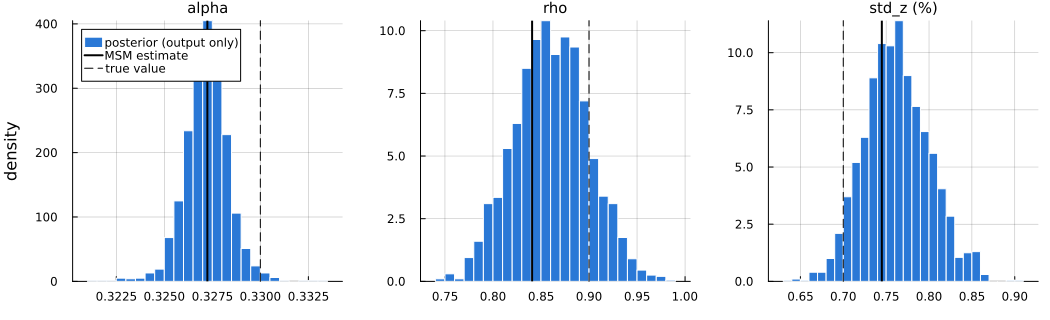

In [21]:
# Posterior distributions, with the MSM estimate and the true value
posteriorPanels = []
for (i, (name, title, f)) in enumerate(zip((:α, :ρ, :log_std_z), ("alpha", "rho", "std_z (%)"), (identity, identity, exp)))
    p = histogram(f.(vec(posteriorDraws[name])), bins = 40, normalize = :pdf, color = colorModel, linecolor = :white,
                  label = "posterior (output only)", title = title, titlefontsize = 10, ylabel = i == 1 ? "density" : "",
                  gridalpha = 0.3, legend = i == 1 ? :topleft : false)
    vline!(p, [f(step2.θ[i])], color = :black, linewidth = 2, label = "MSM estimate")
    vline!(p, [f(trueValues[i])], color = :black, linestyle = :dash, linewidth = 1.0, label = "true value")
    push!(posteriorPanels, p)
end
plot(posteriorPanels..., layout = (1, 3), size = (1050, 320), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
